<a href="https://colab.research.google.com/github/saadbinather/Multi-Factor-Stock-Forecasting-FW/blob/main/Baseline%2Bsentiment%2Beconomic_factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install gnewsclient

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=40d19f9d60467894e9fa85c70e350dbf89a67378cbdcf26e06a97cdc88c2ac2c
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional

from gnewsclient import gnewsclient

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional





/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:


companies_dict = OrderedDict({
    'Amazon':'AMZN',
    'Apple':'AAPL',
    'Nike':'NKE',
    'Google':'GOOGL',
    'META':'META'
})

In [ ]:
!pip install gnews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.2 MB/s eta 0:00:00


In [ ]:
from datetime import datetime

industry_keywords = {
    'Amazon': [
        # Core financial / stock movers
        'Amazon earnings', 'Amazon quarterly results', 'Amazon revenue',
        'Amazon profit', 'AMZN stock', 'Amazon guidance', 'Amazon EPS',
        'Amazon pre-market', 'Amazon after-hours', 'Amazon target price',

        # AWS (biggest valuation driver)
        'AWS earnings', 'Amazon Web Services revenue', 'AWS growth',

        # Major business events
        'Amazon acquisition', 'Amazon partnership', 'Amazon investment',
        'Amazon expansion', 'Amazon Prime', 'Amazon sales',

        # Workforce / major impact news
        'Amazon layoffs', 'Amazon labor union', 'Amazon strike',

        # Regulatory / legal (major stock movers)
        'Amazon lawsuit', 'Amazon antitrust', 'FTC Amazon', 'Amazon investigation',

        # Leadership (only major ones)
        'Andy Jassy Amazon', 'Jeff Bezos Amazon',

        # Market sentiment
        'Amazon analyst', 'Amazon rating', 'Amazon upgrade', 'Amazon downgrade',
        'Amazon price target', 'Amazon bull', 'Amazon bear'
    ],

    'Apple': [
        # Core financial
        'Apple earnings', 'Apple quarterly results', 'Apple revenue',
        'Apple profit', 'AAPL stock', 'Apple guidance', 'Apple EPS',
        'Apple pre-market', 'Apple after-hours', 'Apple target price',

        # Products (stock movers)
        'Apple iPhone', 'iPhone sales', 'iPhone shipment',
        'Apple MacBook', 'Apple iPad', 'Apple Watch', 'Apple Vision Pro',
        'Apple services revenue', 'App Store revenue',

        # Leadership
        'Tim Cook Apple', 'Apple CEO',

        # Business events
        'Apple product launch', 'Apple event', 'Apple supply chain',
        'Apple China', 'Apple production', 'Apple supplier',

        # Capital allocation
        'Apple dividend', 'Apple buyback', 'Apple stock split',

        # Regulatory/legal
        'Apple lawsuit', 'Apple antitrust', 'DOJ Apple', 'Apple EU',

        # Market sentiment
        'Apple analyst', 'Apple rating', 'Apple upgrade', 'Apple downgrade',
        'AAPL price target', 'Apple bull', 'Apple bear'
    ],

    'Nike': [
        # Core financial
        'Nike earnings', 'Nike quarterly results', 'Nike revenue',
        'Nike profit', 'NKE stock', 'Nike guidance', 'Nike EPS',
        'Nike pre-market', 'Nike after-hours',

        # Sales metrics
        'Nike sales', 'Nike direct sales', 'Nike China sales',
        'Nike North America sales', 'Nike inventory',

        # Leadership
        'Nike CEO', 'Nike executive',

        # Business events
        'Nike product launch', 'Nike sponsorship', 'Nike partnership',
        'Nike collaboration', 'Nike brand',

        # Market position
        'Nike market share', 'Nike competition', 'Nike Adidas',

        # Regulatory/legal
        'Nike lawsuit', 'Nike investigation',

        # Market sentiment
        'Nike analyst', 'Nike rating', 'Nike upgrade', 'Nike downgrade',
        'NKE price target', 'Nike bull', 'Nike bear'
    ],

    'Google': [
        # Core financial
'Alphabet 2022 earnings report', 'Google Q1 2023 financial results',
    'Alphabet revenue growth 2022', 'Google 2023 earnings beat miss',
    'GOOGL stock pre-market reaction 2023', 'Alphabet guidance update 2023',

    # Advertising
    'Google search ad revenue 2022', 'YouTube advertising revenue decline 2023',
    'Alphabet digital ad market share 2023', 'Google Ads policy update 2022',

    # Cloud
    'Google Cloud revenue growth 2022', 'GCP reaches profitability 2023',
    'Google Cloud enterprise deals 2023', 'Google Cloud Next announcements 2023',

    # AI (The major 2022-2023 shift)
    'Google announces Bard AI', 'Google response to ChatGPT 2023',
    'Google Gemini launch 2023', 'Google DeepMind merger 2023',
    'Alphabet AI integration announcement 2023', 'Google AI event 2023',

    # Leadership
    'Sundar Pichai memo to employees 2023', 'Alphabet CEO Sundar Pichai interview 2022',
    'Google executive leadership changes 2023',

    # Regulatory
    'DOJ Google antitrust lawsuit 2023', 'Google EU fine ruling 2022',
    'Google ad tech antitrust 2023', 'Alphabet CMA investigation UK 2022',

    # Business events (Cost cutting and major acquisitions)
    'Google announces 12000 layoffs 2023', 'Alphabet cost cutting measures 2022',
    'Google acquires Mandiant 2022', 'Google office closures 2023',

    # Market sentiment
    'GOOGL stock upgraded downgraded 2023', 'Alphabet price target cut 2022',
    'Wall Street analyst GOOGL rating 2023', 'Morgan Stanley Google note 2023'
],

  'META': [
        # Core financial
        'Meta earnings', 'Facebook revenue', 'Meta quarterly results',
        'Meta revenue', 'META stock', 'FB stock', 'Meta profit',
        'Meta guidance', 'Meta EPS', 'Meta pre-market', 'Meta after-hours',

        # Advertising (Fixed generics to be Meta-specific)
        'Meta advertising revenue', 'Facebook ads', 'Instagram ads',
        'Meta ad pricing', 'Facebook ad impressions', 'Meta CPM',

        # Platforms (Fixed generics)
        'Facebook users', 'Instagram growth', 'WhatsApp business', 'Meta Threads',
        'Instagram Reels engagement', 'Facebook daily active users', 'Meta monthly active users',

        # Leadership & Strategy (Added 2022/23 specific context)
        'Mark Zuckerberg Meta', 'Meta CEO', 'Meta Year of Efficiency',

        # Metaverse & AI (Cost centers & pivots)
        'Meta metaverse', 'Reality Labs', 'Meta VR', 'Meta loss',
        'Meta Generative AI', 'Meta LLaMA', # Crucial for 2023 stock movement

        # Efficiency
        'Meta layoffs', 'Meta cost cutting', 'Meta hiring freeze',

        # Competition & Macro (Fixed generics)
        'Meta vs TikTok', 'Facebook Apple privacy', 'Meta iOS update impact',

        # Regulatory
        'Meta lawsuit', 'FTC Meta', 'Instagram safety hearing', 'Meta fine',

        # Market sentiment
        'Meta analyst', 'META rating', 'Meta upgrade', 'Meta downgrade',
        'Meta price target', 'Meta bull', 'Meta bear'
    ]}

# Date range
start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 1, 15)

# Initialize GNews client
client = gnewsclient.NewsClient(language='english', location='Pakistan', max_results=100)

In [ ]:
pip install GoogleNews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
from gnews import GNews
import pandas as pd

all_news = []

for keyword in industry_keywords['Amazon']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_amazon = pd.DataFrame(all_news).drop_duplicates()

df_amazon['date'] = pd.to_datetime(df_amazon['date'], errors='coerce')
df_amazon = df_amazon.dropna(subset=['date'])
df_amazon = df_amazon.sort_values(by='date')

print(df_amazon.head())

                    date                                              title  \
689  2022-01-02 08:00:00  Will Alibaba Be Worth More Than Amazon by 2030...   
1803 2022-01-03 08:00:00  Amazon must face biometric privacy lawsuit ove...   
2549 2022-01-05 08:00:00  Onfido’s Journey to a Multi-Cluster Amazon EKS...   
963  2022-01-05 08:00:00  Amazon and Stellantis Collaborate to Introduce...   
58   2022-01-05 08:00:00  Amazon was the worst-performing FAANG stock of...   

                                            description  
689   Will Alibaba Be Worth More Than Amazon by 2030...  
1803  Amazon must face biometric privacy lawsuit ove...  
2549  Onfido’s Journey to a Multi-Cluster Amazon EKS...  
963   Amazon and Stellantis Collaborate to Introduce...  
58    Amazon was the worst-performing FAANG stock of...  


In [ ]:
df_amazon.shape

(2198, 3)

In [ ]:
all_news = []

for keyword in industry_keywords['Apple']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_apple = pd.DataFrame(all_news).drop_duplicates()

df_apple['date'] = pd.to_datetime(df_apple['date'], errors='coerce')
df_apple = df_apple.dropna(subset=['date'])
df_apple = df_apple.sort_values(by='date')

print(df_apple.head())

                    date                                              title  \
2478 2022-01-01 08:00:00  Competition Commission of India Orders Investi...   
1593 2022-01-02 08:00:00  Apple Set to Step Up Product Launches in 2022 ...   
3102 2022-01-02 08:00:00  A look back: The Waffle Iron Cafe in Apple Val...   
2211 2022-01-02 08:00:00  How Apple trade-in turned my broken MacBook Pr...   
1627 2022-01-03 08:00:00  Apple's 2022 products tipped — iPhone 14 with ...   

                                            description  
2478  Competition Commission of India Orders Investi...  
1593  Apple Set to Step Up Product Launches in 2022 ...  
3102  A look back: The Waffle Iron Cafe in Apple Val...  
2211  How Apple trade-in turned my broken MacBook Pr...  
1627  Apple's 2022 products tipped — iPhone 14 with ...  


In [ ]:
all_news = []

for keyword in industry_keywords['Nike']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_nike = pd.DataFrame(all_news).drop_duplicates()

df_nike['date'] = pd.to_datetime(df_nike['date'], errors='coerce')
df_nike = df_nike.dropna(subset=['date'])
df_nike = df_nike.sort_values(by='date')

print(df_nike.head())

                    date                                              title  \
301  2022-01-03 08:00:00  Guggenheim names Nike its best idea for 2022, ...   
134  2022-01-03 08:00:00  Are Nike’s Member Days loyalty’s future? - Ret...   
1553 2022-01-04 08:00:00  15 of the best activewear brands of 2023 - Bea...   
1660 2022-01-05 08:00:00  FOS PM: Nike Sues Lululemon - Front Office Sports   
616  2022-01-05 08:00:00  Anta Gaining Ground on Rivals Nike, Adidas, Pu...   

                                            description  
301   Guggenheim names Nike its best idea for 2022, ...  
134   Are Nike’s Member Days loyalty’s future?  Reta...  
1553  15 of the best activewear brands of 2023  Bear...  
1660   FOS PM: Nike Sues Lululemon  Front Office Sports  
616   Anta Gaining Ground on Rivals Nike, Adidas, Pu...  


In [ ]:
all_news = []

for keyword in industry_keywords['Google']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_google = pd.DataFrame(all_news).drop_duplicates()

df_google['date'] = pd.to_datetime(df_google['date'], errors='coerce')
df_google = df_google.dropna(subset=['date'])
df_google = df_google.sort_values(by='date')

print(df_google.head())

                   date                                              title  \
153 2022-01-04 08:00:00  Investor Michael Seibel Explains Google’s Sear...   
926 2022-01-05 08:00:00  Amazon was the worst-performing FAANG stock of...   
785 2022-01-06 08:00:00  France spanks Google $170M, Facebook $68M over...   
766 2022-01-06 08:00:00  Google hit with 150 mln euro French fine for c...   
784 2022-01-06 08:00:00  France fines Google and Facebook €210m over us...   

                                           description  
153  Investor Michael Seibel Explains Google’s Sear...  
926  Amazon was the worst-performing FAANG stock of...  
785  France spanks Google $170M, Facebook $68M over...  
766  Google hit with 150 mln euro French fine for c...  
784  France fines Google and Facebook €210m over us...  


In [ ]:
all_news = []

for keyword in industry_keywords['META']:

    google_news = GNews(language='en', country='US', max_results=100)
    google_news.start_date = (2022, 1, 1)
    google_news.end_date   = (2023, 1, 15)

    news = google_news.get_news(keyword)

    for article in news:
        all_news.append({
            "date": article.get("published date"),
            "title": article.get("title"),
            "description": article.get("description")
        })

df_meta = pd.DataFrame(all_news).drop_duplicates()

df_meta['date'] = pd.to_datetime(df_meta['date'], errors='coerce')
df_meta = df_meta.dropna(subset=['date'])
df_meta = df_meta.sort_values(by='date')

print(df_meta.head())

                    date                                              title  \
928  2022-01-02 08:00:00  Facebook ad ban may squelch medical research r...   
3059 2022-01-03 06:17:27  Meta Business Systems Analyst Salaries in New ...   
1662 2022-01-03 08:00:00  Decentraland Holds First-Mover Advantage in Ba...   
1952 2022-01-04 08:00:00            Money in the Metaverse - The New Yorker   
3288 2022-01-04 08:00:00  Gender, Socioeconomic Status, Cultural Differe...   

                                            description  
928   Facebook ad ban may squelch medical research r...  
3059  Meta Business Systems Analyst Salaries in New ...  
1662  Decentraland Holds First-Mover Advantage in Ba...  
1952             Money in the Metaverse  The New Yorker  
3288  Gender, Socioeconomic Status, Cultural Differe...  


In [ ]:
df_meta.head()

,date,title,description
928,2022-01-02 08:00:00,Facebook ad ban may squelch medical research r...,Facebook ad ban may squelch medical research r...
3059,2022-01-03 06:17:27,Meta Business Systems Analyst Salaries in New ...,Meta Business Systems Analyst Salaries in New ...
1662,2022-01-03 08:00:00,Decentraland Holds First-Mover Advantage in Ba...,Decentraland Holds First-Mover Advantage in Ba...
1952,2022-01-04 08:00:00,Money in the Metaverse - The New Yorker,Money in the Metaverse The New Yorker
3288,2022-01-04 08:00:00,"Gender, Socioeconomic Status, Cultural Differe...","Gender, Socioeconomic Status, Cultural Differe..."


In [ ]:
!pip install transformers torch

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

labels = ['negative', 'neutral', 'positive']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_finbert_sentiment(text):

    if pd.isna(text):
        return 0

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    sentiment = torch.argmax(probs).item()
    label = labels[sentiment]

    if label == 'positive':
        return 1
    elif label == 'negative':
        return -1
    else:
        return 0

In [ ]:
df_amazon['text'] = df_amazon['title'].fillna('') + " " + df_amazon['description'].fillna('')
df_amazon['sentiment'] = df_amazon['text'].apply(get_finbert_sentiment)


df_amazon['date_only'] = df_amazon['date'].dt.date

daily_amazon = df_amazon.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()


In [ ]:
df_apple['text'] = df_apple['title'].fillna('') + " " + df_apple['description'].fillna('')
df_apple['sentiment'] = df_apple['text'].apply(get_finbert_sentiment)


df_apple['date_only'] = df_apple['date'].dt.date
daily_apple = df_apple.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()

In [ ]:


df_nike['text'] = df_nike['title'].fillna('') + " " + df_nike['description'].fillna('')
df_nike['sentiment'] = df_nike['text'].apply(get_finbert_sentiment)


df_nike['date_only'] = df_nike['date'].dt.date
daily_nike = df_nike.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()





In [ ]:

df_google['text'] = df_google['title'].fillna('') + " " + df_google['description'].fillna('')
df_google['sentiment'] = df_google['text'].apply(get_finbert_sentiment)



df_google['date_only'] = df_google['date'].dt.date
daily_google = df_google.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()



In [ ]:
df_meta['text'] = df_meta['title'] + " " + df_meta['description']
df_meta['sentiment'] = df_meta['text'].apply(get_finbert_sentiment)



df_meta['date_only'] = df_meta['date'].dt.date
daily_meta = df_meta.groupby('date_only').agg({
    'sentiment': 'mean',
    'title': 'count'
}).rename(columns={'title': 'news_count'}).reset_index()

In [ ]:
daily_meta.shape



(342, 3)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("APPLE (AAPL) - With Rolling Mean")
print("="*50)

# Download Apple stock data
aapl_stock = yf.download("AAPL", start=start, end=end)

# Flatten MultiIndex columns
aapl_stock.columns = aapl_stock.columns.get_level_values(0)

# Reset index and create date column
aapl_stock = aapl_stock.reset_index()
aapl_stock['date_only'] = aapl_stock['Date'].dt.date

# Merge with sentiment data
df_apple_final = pd.merge(
    aapl_stock,
    daily_apple[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_apple_final = df_apple_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
#df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(   df_apple_final['sentiment'].rolling(30, min_periods=1).mean())
df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_apple_final = df_apple_final.drop(columns=['date_only'])

# Rename to df_apple
df_apple = df_apple_final

# Display results
print(f"\n📊 Apple Statistics:")
print(f"Total rows: {len(df_apple)}")
print(f"Date range: {df_apple['Date'].min()} to {df_apple['Date'].max()}")
print(f"Sentiment - Mean: {df_apple['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_apple['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_apple['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_apple['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_apple.head()

APPLE (AAPL) - With Rolling Mean


/tmp/ipykernel_2629/1596574591.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_stock = yf.download("AAPL", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


📊 Apple Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.7095
Sentiment - Std: 0.2582
Sentiment - Min: 0.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_2629/1596574591.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_apple_final['sentiment'] = df_apple_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,178.103622,178.954960,173.895923,174.013342,104487900,0.714286
1,2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400,0.333333
2,2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600,0.600000
3,2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000,0.833333
4,2022-01-07,168.474869,170.402590,167.359336,169.179417,86709100,0.571429


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("AMAZON (AMZN) - With Rolling Mean")
print("="*50)

# Download Amazon stock data
amzn_stock = yf.download("AMZN", start=start, end=end)

# Flatten MultiIndex columns
amzn_stock.columns = amzn_stock.columns.get_level_values(0)

# Reset index and create date column
amzn_stock = amzn_stock.reset_index()
amzn_stock['date_only'] = amzn_stock['Date'].dt.date

# Merge with sentiment data
df_amazon_final = pd.merge(
    amzn_stock,
    daily_amazon[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_amazon_final = df_amazon_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
#df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(   df_amazon_final['sentiment'].rolling(30, min_periods=1).mean())
df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(0)


# Forward fill any remaining NaN at the beginning
df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_amazon_final = df_amazon_final.drop(columns=['date_only'])

# Rename to df_amazon
df_amazon = df_amazon_final

# Display results
print(f"\n📊 Amazon Statistics:")
print(f"Total rows: {len(df_amazon)}")
print(f"Date range: {df_amazon['Date'].min()} to {df_amazon['Date'].max()}")
print(f"Sentiment - Mean: {df_amazon['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_amazon['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_amazon['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_amazon['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_amazon.head()

/tmp/ipykernel_2629/3216568526.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_stock = yf.download("AMZN", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


AMAZON (AMZN) - With Rolling Mean

📊 Amazon Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.6635
Sentiment - Std: 0.3012
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:


/tmp/ipykernel_2629/3216568526.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_amazon_final['sentiment'] = df_amazon_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,170.404495,170.703506,166.160507,167.550003,63520000,1.0
1,2022-01-04,167.522003,171.399994,166.349503,170.438004,70726000,0.0
2,2022-01-05,164.356995,167.126495,164.356995,166.882996,64302000,0.5
3,2022-01-06,163.253998,164.800003,161.936996,163.450500,51958000,1.0
4,2022-01-07,162.554001,165.243500,162.031006,163.839005,46606000,0.5


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("NIKE (NKE) - With Rolling Mean")
print("="*50)

# Download Nike stock data
nke_stock = yf.download("NKE", start=start, end=end)

# Flatten MultiIndex columns
nke_stock.columns = nke_stock.columns.get_level_values(0)

# Reset index and create date column
nke_stock = nke_stock.reset_index()
nke_stock['date_only'] = nke_stock['Date'].dt.date

# Merge with sentiment data
df_nike_final = pd.merge(
    nke_stock,
    daily_nike[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_nike_final = df_nike_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
#df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(df_nike_final['sentiment'].rolling(30, min_periods=1).mean())

df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_nike_final = df_nike_final.drop(columns=['date_only'])

# Rename to df_nike
df_nike = df_nike_final

# Display results
print(f"\n📊 Nike Statistics:")
print(f"Total rows: {len(df_nike)}")
print(f"Date range: {df_nike['Date'].min()} to {df_nike['Date'].max()}")
print(f"Sentiment - Mean: {df_nike['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_nike['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_nike['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_nike['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_nike.head()

NIKE (NKE) - With Rolling Mean


/tmp/ipykernel_2629/46540010.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nke_stock = yf.download("NKE", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


📊 Nike Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.7446
Sentiment - Std: 0.3385
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_2629/46540010.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nike_final['sentiment'] = df_nike_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,153.479996,156.499830,152.212413,156.145648,5670500,1.0
1,2022-01-04,155.083069,155.819379,153.787526,154.607731,6064200,1.0
2,2022-01-05,151.224426,155.660959,151.084625,155.176305,5021000,0.0
3,2022-01-06,150.096634,152.100541,148.251187,151.075285,4144600,0.4
4,2022-01-07,146.303207,150.189836,146.200682,149.844984,5108000,0.0


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("GOOGLE (GOOGL) - With Rolling Mean")
print("="*50)

# Download Google stock data
googl_stock = yf.download("GOOGL", start=start, end=end)

# Flatten MultiIndex columns
googl_stock.columns = googl_stock.columns.get_level_values(0)

# Reset index and create date column
googl_stock = googl_stock.reset_index()
googl_stock['date_only'] = googl_stock['Date'].dt.date

# Merge with sentiment data
df_google_final = pd.merge(
    googl_stock,
    daily_google[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_google_final = df_google_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
#df_google_final['sentiment'] = df_google_final['sentiment'].fillna(df_google_final['sentiment'].rolling(30, min_periods=1).mean())

df_google_final['sentiment'] = df_google_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_google_final['sentiment'] = df_google_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_google_final = df_google_final.drop(columns=['date_only'])

# Rename to df_google
df_google = df_google_final

# Display results
print(f"\n📊 Google Statistics:")
print(f"Total rows: {len(df_google)}")
print(f"Date range: {df_google['Date'].min()} to {df_google['Date'].max()}")
print(f"Sentiment - Mean: {df_google['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_google['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_google['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_google['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_google.head()

/tmp/ipykernel_2629/1032288225.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  googl_stock = yf.download("GOOGL", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

GOOGLE (GOOGL) - With Rolling Mean

📊 Google Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.5636
Sentiment - Std: 0.4702
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_2629/1032288225.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_google_final['sentiment'] = df_google_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,143.802963,144.655415,142.534940,143.865935,28646000,0.000000
1,2022-01-04,143.215790,145.284189,142.538390,144.204112,28400000,0.000000
2,2022-01-05,136.645599,143.314979,136.559322,143.236132,54618000,0.000000
3,2022-01-06,136.618347,138.792880,135.439098,135.875494,37348000,0.333333
4,2022-01-07,135.893829,137.313598,134.653577,137.013073,29760000,0.000000


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

start = "2022-01-01"
end = "2023-01-15"

print("="*50)
print("META (META) - With Rolling Mean")
print("="*50)

# Download Meta stock data
meta_stock = yf.download("META", start=start, end=end)

# Flatten MultiIndex columns
meta_stock.columns = meta_stock.columns.get_level_values(0)

# Reset index and create date column
meta_stock = meta_stock.reset_index()
meta_stock['date_only'] = meta_stock['Date'].dt.date

# Merge with sentiment data
df_meta_final = pd.merge(
    meta_stock,
    daily_meta[['date_only', 'sentiment']],
    on='date_only',
    how='left'
)

# Sort by date
df_meta_final = df_meta_final.sort_values('Date')

# Fill NaN with rolling mean (30-day window)
#df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(df_meta_final['sentiment'].rolling(30, min_periods=1).mean())


df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(0)

# Forward fill any remaining NaN at the beginning
df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(method='ffill').fillna(method='bfill')

# Drop date_only column
df_meta_final = df_meta_final.drop(columns=['date_only'])

# Rename to df_meta
df_meta = df_meta_final

# Display results
print(f"\n📊 Meta Statistics:")
print(f"Total rows: {len(df_meta)}")
print(f"Date range: {df_meta['Date'].min()} to {df_meta['Date'].max()}")
print(f"Sentiment - Mean: {df_meta['sentiment'].mean():.4f}")
print(f"Sentiment - Std: {df_meta['sentiment'].std():.4f}")
print(f"Sentiment - Min: {df_meta['sentiment'].min():.4f}")
print(f"Sentiment - Max: {df_meta['sentiment'].max():.4f}")

print("\n📋 First 5 rows:")
df_meta.head()

/tmp/ipykernel_2629/2173615185.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  meta_stock = yf.download("META", start=start, end=end)


META (META) - With Rolling Mean


[*********************100%***********************]  1 of 1 completed


📊 Meta Statistics:
Total rows: 260
Date range: 2022-01-03 00:00:00 to 2023-01-13 00:00:00
Sentiment - Mean: 0.7196
Sentiment - Std: 0.2831
Sentiment - Min: -1.0000
Sentiment - Max: 1.0000

📋 First 5 rows:



/tmp/ipykernel_2629/2173615185.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_meta_final['sentiment'] = df_meta_final['sentiment'].fillna(method='ffill').fillna(method='bfill')


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,335.903992,338.424192,334.564497,335.665840,14537900,0.500000
1,2022-01-04,333.909668,340.418587,329.285949,337.303052,15998000,1.000000
2,2022-01-05,321.645905,333.145657,321.318457,330.426971,20564500,1.000000
3,2022-01-06,329.871368,336.529144,320.207216,320.306444,27962800,0.750000
4,2022-01-07,329.206573,334.375998,326.319228,330.149158,14722000,0.666667


In [ ]:
company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta
}

def create_sequences_multivariate(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])

        y.append(data[i, 3])  # Only predict Close price

    return np.array(X), np.array(y)

In [ ]:
company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Google": df_google,
    "Meta": df_meta,
    "Nike": df_nike
}


df_amazon.head()


,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,170.404495,170.703506,166.160507,167.550003,63520000,1.0
1,2022-01-04,167.522003,171.399994,166.349503,170.438004,70726000,0.0
2,2022-01-05,164.356995,167.126495,164.356995,166.882996,64302000,0.5
3,2022-01-06,163.253998,164.800003,161.936996,163.450500,51958000,1.0
4,2022-01-07,162.554001,165.243500,162.031006,163.839005,46606000,0.5


In [ ]:
df_google.head()

,Date,Close,High,Low,Open,Volume,sentiment
0,2022-01-03,143.802963,144.655415,142.534940,143.865935,28646000,0.000000
1,2022-01-04,143.215790,145.284189,142.538390,144.204112,28400000,0.000000
2,2022-01-05,136.645599,143.314979,136.559322,143.236132,54618000,0.000000
3,2022-01-06,136.618347,138.792880,135.439098,135.875494,37348000,0.333333
4,2022-01-07,135.893829,137.313598,134.653577,137.013073,29760000,0.000000


In [ ]:
import yfinance as yf
import pandas as pd

# Macro tickers aur simple naam
macro_tickers = {
    '^GSPC': 'SP500',
    'GC=F': 'Gold',
    'CL=F': 'Oil',
    'BTC-USD': 'BTC'
}

macro_data = pd.DataFrame()

print("Downloading Macro Data one by one...")

# Macro data download
for ticker, name in macro_tickers.items():
    temp_data = yf.download(
        ticker,
        start='2021-12-20',
        end='2024-01-15',
        progress=False,
        auto_adjust=True
    )

    macro_data[name] = temp_data['Close']

# Date column banayein
macro_data.reset_index(inplace=True)
macro_data['Date'] = pd.to_datetime(macro_data['Date'])

# =========================
# Merge with company data
# =========================

for company_name, df in company_dfs.items():

    df['Date'] = pd.to_datetime(df['Date'])

    merged_df = pd.merge(df, macro_data, on='Date', how='left')

    # Agar pehle se macro columns exist karte ho to pandas _x _y bana deta hai
    if 'SP500_y' in merged_df.columns:

        merged_df[['SP500_y','Gold_y','Oil_y','BTC_y']] = \
        merged_df[['SP500_y','Gold_y','Oil_y','BTC_y']].ffill().bfill()

        merged_df.rename(columns={
            'SP500_y':'SP500',
            'Gold_y':'Gold',
            'Oil_y':'Oil',
            'BTC_y':'BTC'
        }, inplace=True)

        merged_df.drop(columns=['SP500_x','Gold_x','Oil_x','BTC_x'], errors='ignore', inplace=True)

    else:

        merged_df[['SP500','Gold','Oil','BTC']] = \
        merged_df[['SP500','Gold','Oil','BTC']].ffill().bfill()

    company_dfs[company_name] = merged_df


# Updated dataframes
df_amazon = company_dfs['Amazon']
df_apple = company_dfs['Apple']
df_google = company_dfs['Google']
df_meta = company_dfs['Meta']
df_nike = company_dfs['Nike']


print(df_amazon.head())

        Date       Close        High         Low        Open    Volume  \
0 2022-01-03  170.404495  170.703506  166.160507  167.550003  63520000   
1 2022-01-04  167.522003  171.399994  166.349503  170.438004  70726000   
2 2022-01-05  164.356995  167.126495  164.356995  166.882996  64302000   
3 2022-01-06  163.253998  164.800003  161.936996  163.450500  51958000   
4 2022-01-07  162.554001  165.243500  162.031006  163.839005  46606000   

   sentiment        SP500         Gold        Oil           BTC  
0        1.0  4796.560059  1799.400024  76.080002  46458.117188  
1        0.0  4793.540039  1814.000000  76.989998  45897.574219  
2        0.5  4700.580078  1824.599976  77.849998  43569.003906  
3        1.0  4696.049805  1788.699951  79.459999  43160.929688  
4        0.5  4677.029785  1797.000000  78.900002  41557.902344  


In [ ]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,sentiment,SP500,Gold,Oil,BTC
0,2022-01-03,153.479996,156.499830,152.212413,156.145648,5670500,1.0,4796.560059,1799.400024,76.080002,46458.117188
1,2022-01-04,155.083069,155.819379,153.787526,154.607731,6064200,1.0,4793.540039,1814.000000,76.989998,45897.574219
2,2022-01-05,151.224426,155.660959,151.084625,155.176305,5021000,0.0,4700.580078,1824.599976,77.849998,43569.003906
3,2022-01-06,150.096634,152.100541,148.251187,151.075285,4144600,0.4,4696.049805,1788.699951,79.459999,43160.929688
4,2022-01-07,146.303207,150.189836,146.200682,149.844984,5108000,0.0,4677.029785,1797.000000,78.900002,41557.902344


In [ ]:
df_amazon.head()

,Date,Close,High,Low,Open,Volume,sentiment,SP500,Gold,Oil,BTC
0,2022-01-03,170.404495,170.703506,166.160507,167.550003,63520000,1.0,4796.560059,1799.400024,76.080002,46458.117188
1,2022-01-04,167.522003,171.399994,166.349503,170.438004,70726000,0.0,4793.540039,1814.000000,76.989998,45897.574219
2,2022-01-05,164.356995,167.126495,164.356995,166.882996,64302000,0.5,4700.580078,1824.599976,77.849998,43569.003906
3,2022-01-06,163.253998,164.800003,161.936996,163.450500,51958000,1.0,4696.049805,1788.699951,79.459999,43160.929688
4,2022-01-07,162.554001,165.243500,162.031006,163.839005,46606000,0.5,4677.029785,1797.000000,78.900002,41557.902344


In [ ]:
for df in [df_amazon, df_apple, df_nike, df_google, df_meta]:
    df['Oil_Return'] = df['Oil'].pct_change()

In [ ]:
for df in [df_amazon, df_apple, df_nike, df_google, df_meta]:
    df['Gold_Return'] = df['Gold'].pct_change()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ridge_results = []
ridge_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta

}

for company_name, df in company_dfs.items():

    print(f"Processing (Ridge) {company_name}...")

    df = df.copy()
    df.set_index("Date", inplace=True)

    # Create extra feature
    df['Price_Movement'] = df['Close'] - df['Open']

    df.dropna(inplace=True)

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # 🔥 Features (include sentiment)
    X = df[['Open', 'High', 'Low', 'Volume', 'sentiment' , 'Price_Movement']]
    y = df['Close']

    # Time-based split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df.index[split_index:]

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Train Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_scaled)

    # Predict
    pred_scaled = ridge.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    ridge_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    ridge_plot_data[company_name] = (test_dates, y_test_actual, predictions)

pd.DataFrame(ridge_results)

Processing (Ridge) Amazon...
Processing (Ridge) Apple...
Processing (Ridge) Nike...
Processing (Ridge) Google...
Processing (Ridge) Meta...


,Company,RMSE,MAE
0,Amazon,0.90,0.83
1,Apple,0.70,0.56
2,Nike,0.32,0.26
3,Google,0.68,0.63
4,Meta,1.89,1.83


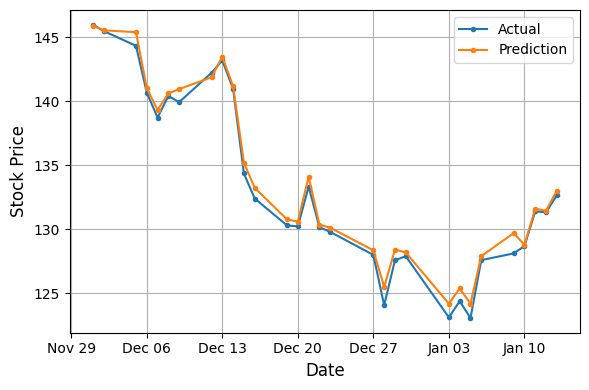

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

os.makedirs("F10", exist_ok=True)

for company_name in ridge_plot_data:
  if company_name=='Apple':
    dates, actual, predicted = ridge_plot_data[company_name]

    plt.figure(figsize=(6,4))

    # Plot lines with markers
    plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
    plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

    # Labels
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Stock Price", fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.tight_layout()




    # ✅ Then show
    plt.show()

    # Close the figure
    plt.close()

In [ ]:
df_apple.head()

,Date,Close,High,Low,Open,Volume,sentiment,SP500,Gold,Oil,BTC,Oil_Return,Gold_Return
0,2022-01-03,178.103622,178.954960,173.895923,174.013342,104487900,0.714286,4796.560059,1799.400024,76.080002,46458.117188,NaN,NaN
1,2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400,0.333333,4793.540039,1814.000000,76.989998,45897.574219,0.011961,0.008114
2,2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600,0.600000,4700.580078,1824.599976,77.849998,43569.003906,0.011170,0.005843
3,2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000,0.833333,4696.049805,1788.699951,79.459999,43160.929688,0.020681,-0.019676
4,2022-01-07,168.474869,170.402590,167.359336,169.179417,86709100,0.571429,4677.029785,1797.000000,78.900002,41557.902344,-0.007048,0.004640


In [ ]:
#Global Ridge 5

from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ridge_results = []
ridge_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_train_X = []
all_train_y = []

processed_dfs = {}

split_date = "2022-12-01"

for company_name, df in company_dfs.items():

    df = df.copy()
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    else:
        df.index = pd.to_datetime(df.index)

    # Feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df.dropna(inplace=True)

    split_index = df.index.get_loc(split_date)

    X = df[['Open', 'High', 'Low', 'Volume', 'sentiment','Oil', 'Price_Movement']]
    y = df['Close']

    # Split
    X_train = X.iloc[:split_index]
    y_train = y.iloc[:split_index]

    # Store for global training
    all_train_X.append(X_train)
    all_train_y.append(y_train)

    # Save test separately
    processed_dfs[company_name] = {
        "df": df,
        "X_test": X.iloc[split_index:],
        "y_test": y.iloc[split_index:],
        "dates": df.index[split_index:]
    }

# =========================
# STEP 2 — Combine ALL companies
# =========================

X_train_global = pd.concat(all_train_X)
y_train_global = pd.concat(all_train_y)

# =========================
# STEP 3 — Scaling
# =========================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_global)
y_train_scaled = scaler_y.fit_transform(y_train_global.values.reshape(-1, 1)).ravel()

# =========================
# STEP 4 — Train ONE model
# =========================

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_scaled)

# =========================
# STEP 5 — Test per company
# =========================

for company_name, data in processed_dfs.items():

    print(f"Testing (Global Ridge) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    test_dates = data["dates"]

    X_test_scaled = scaler_X.transform(X_test)

    pred_scaled = ridge.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    y_test_actual = y_test.values

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    ridge_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    ridge_plot_data[company_name] = (test_dates, y_test_actual, predictions)

# Final results
pd.DataFrame(ridge_results)

Testing (Global Ridge) Amazon...
Testing (Global Ridge) Apple...
Testing (Global Ridge) Nike...
Testing (Global Ridge) Google...
Testing (Global Ridge) Meta...


,Company,RMSE,MAE
0,Amazon,0.64,0.58
1,Apple,0.40,0.32
2,Nike,0.38,0.32
3,Google,0.61,0.56
4,Meta,0.45,0.33


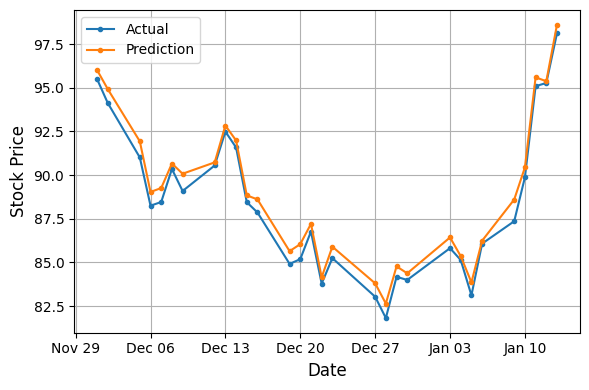

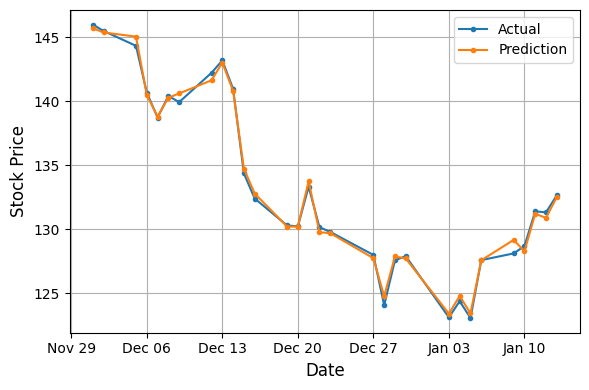

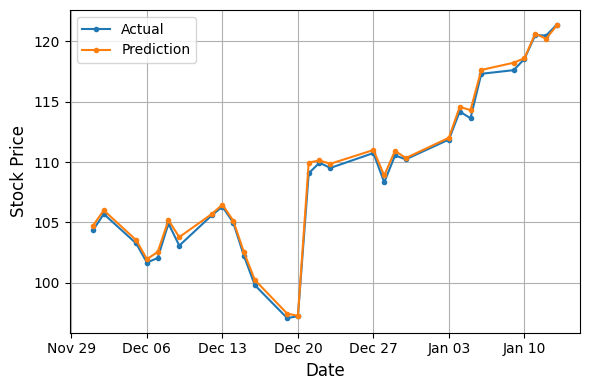

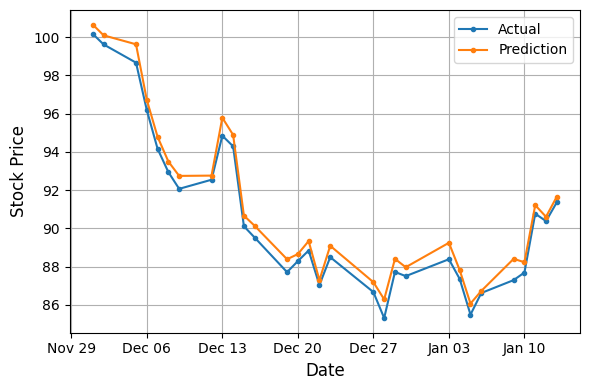

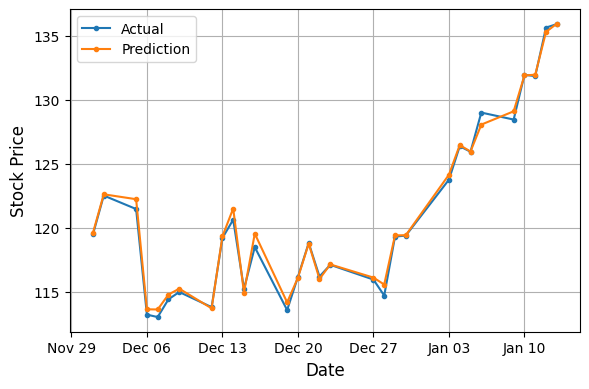

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

os.makedirs("F10", exist_ok=True)

for company_name in ridge_plot_data:
    dates, actual, predicted = ridge_plot_data[company_name]

    plt.figure(figsize=(6,4))

    # Plot lines with markers
    plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
    plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

    # Labels
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Stock Price", fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # ✅ Save first
    filename = f"F10/{company_name}_ridge_oil.png"
    plt.savefig(filename, dpi=300)

    # ✅ Then show
    plt.show()

    # Close the figure
    plt.close()

Correlation matrix:
            BTC      Gold       Oil
BTC   1.000000  0.712475  0.402992
Gold  0.712475  1.000000  0.478399
Oil   0.402992  0.478399  1.000000


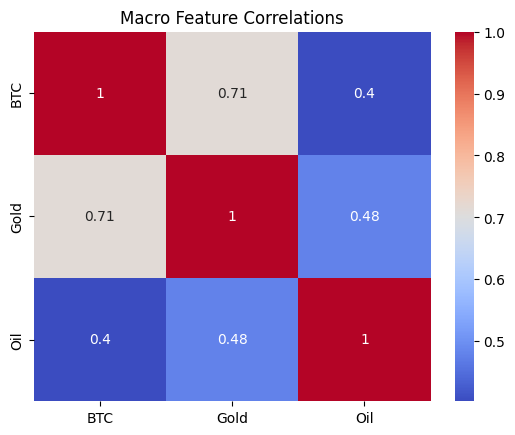

        Date       Close        High         Low        Open   Volume  \
0 2022-01-03  153.479996  156.499830  152.212413  156.145648  5670500   
1 2022-01-04  155.083069  155.819379  153.787526  154.607731  6064200   
2 2022-01-05  151.224426  155.660959  151.084625  155.176305  5021000   
3 2022-01-06  150.096634  152.100541  148.251187  151.075285  4144600   
4 2022-01-07  146.303207  150.189836  146.200682  149.844984  5108000   

   sentiment        SP500  Oil_Return  Gold_Return  Macro_PC1  Macro_PC2  
0        1.0  4796.560059         NaN          NaN   0.372820  -1.995368  
1        1.0  4793.540039    0.011961     0.008114   0.474858  -1.951002  
2        0.0  4700.580078    0.011170     0.005843   0.443894  -1.821777  
3        0.4  4696.049805    0.020681    -0.019676   0.241080  -1.592097  
4        0.0  4677.029785   -0.007048     0.004640   0.180703  -1.584199  


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Suppose your merged_df has macro features
macro_features = ['BTC', 'Gold', 'Oil']

# 1️⃣ Check correlations
corr_matrix = merged_df[macro_features].corr()
print("Correlation matrix:\n", corr_matrix)

# Optional: heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Macro Feature Correlations")
plt.show()

# 2️⃣ If highly correlated, do PCA to reduce to 1 or 2 components
scaler = StandardScaler()
macro_scaled = scaler.fit_transform(merged_df[macro_features])

pca = PCA(n_components=2)  # Reduce to 2 principal components
macro_pca = pca.fit_transform(macro_scaled)

# Convert to dataframe to merge with original features
macro_pca_df = pd.DataFrame(macro_pca, columns=['Macro_PC1', 'Macro_PC2'])
macro_pca_df.index = merged_df.index

# Replace original macro features with PCA components
merged_df = merged_df.drop(columns=macro_features)
merged_df = pd.concat([merged_df, macro_pca_df], axis=1)

print(merged_df.head())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
def create_sequences_multivariate(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])  # Close price index
    return np.array(X), np.array(y)

In [ ]:
results = []
plot_data = {}

# Map company name to dataframe
company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta

}

for company_name, df in company_dfs.items():

    # Set Date as index
    df = df.copy()
    df.set_index("Date", inplace=True)

    # Create Price_Movement feature before selecting columns
    df['Price_Movement'] = df['Close'] - df['Open']

    # Use stock features + sentiment
    # Ensure 'Close' is at index 3 for create_sequences_multivariate
    df_model_features = df[['Open', 'High', 'Low', 'Close', 'Volume','Oil' ,'sentiment', 'Price_Movement']]
    df_model_features.dropna(inplace=True)

    # Scale
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df_model_features)

    seq_length = 30
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    # Split date
    split_date = "2022-12-01"
    split_index = df_model_features.index.get_loc(split_date)
    split_index = split_index - seq_length

    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    test_dates = df_model_features.index[seq_length + split_index:]

    # LSTM Model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 6)
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    predictions = model.predict(X_test, verbose=0)

    # Reconstruct full feature space for inverse scaling
    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    last_sequences = X_test[:, -1, :]
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()  # Close index

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # True values inverse transform
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()
    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    plot_data[company_name] = (test_dates, y_test_actual, predictions_close)


/tmp/ipykernel_2629/4221938349.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/4221938349.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/4221938349.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/4221938349.py:26: SettingWithCopyWarning: 
A value

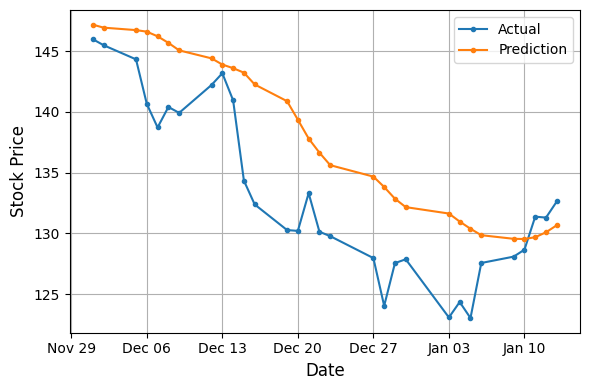

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)



  Company  RMSE   MAE
0  Amazon  3.96  3.08
1   Apple  5.80  4.93
2    Nike  8.26  7.50
3  Google  3.02  2.53
4    Meta  6.24  4.95


In [ ]:
#GLOBAL LSTM----

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

results = []
plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_scaled_data = []
processed_data = {}

seq_length = 30
split_date = "2022-12-01"

for company_name, df in company_dfs.items():

    df = df.copy()
    df.set_index("Date", inplace=True)

    df['Price_Movement'] = df['Close'] - df['Open']

    df_model_features = df[['Open','High','Low','Close','Volume','Oil','sentiment','Price_Movement']]
    df_model_features.dropna(inplace=True)

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df_model_features)

    X, y = create_sequences_multivariate(scaled_data, seq_length)

    split_index = df_model_features.index.get_loc(split_date)
    split_index = split_index - seq_length

    # Store training data globally
    all_scaled_data.append((X[:split_index], y[:split_index]))

    # Store test data per company
    processed_data[company_name] = {
        "X_test": X[split_index:],
        "y_test": y[split_index:],
        "scaled_data": scaled_data,
        "scaler": scaler,
        "dates": df_model_features.index[seq_length + split_index:]
    }

# =========================
# STEP 2 — Combine ALL training data
# =========================

X_train_global = np.concatenate([item[0] for item in all_scaled_data], axis=0)
y_train_global = np.concatenate([item[1] for item in all_scaled_data], axis=0)

# =========================
# STEP 3 — Train ONE LSTM
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train_global.shape[1], X_train_global.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X_train_global,
    y_train_global,
    epochs=20,
    batch_size=32,
    verbose=1
)

# =========================
# STEP 4 — Test per company
# =========================

for company_name, data in processed_data.items():

    print(f"Testing (Global LSTM) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    scaler = data["scaler"]
    scaled_data = data["scaled_data"]
    test_dates = data["dates"]

    predictions = model.predict(X_test, verbose=0)

    # Reconstruct for inverse scaling
    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    last_sequences = X_test[:, -1, :]
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # True values
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()
    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    plot_data[company_name] = (test_dates, y_test_actual, predictions_close)

# Final results
re=pd.DataFrame(results)
re

Epoch 1/20


/tmp/ipykernel_2629/3150330139.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/3150330139.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/3150330139.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_features.dropna(inplace=True)
/tmp/ipykernel_2629/3150330139.py:37: SettingWithCopyWarning: 
A value

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0263
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0111
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0091
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0083
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046
Epoch 16/20
32/32 ━━━━━━━━━━━━

Testing (Global LSTM) Apple...
Testing (Global LSTM) Nike...
Testing (Global LSTM) Google...
Testing (Global LSTM) Meta...


,Company,RMSE,MAE
0,Amazon,2.89,2.10
1,Apple,2.98,2.56
2,Nike,5.28,4.26
3,Google,2.11,1.75
4,Meta,5.54,4.68


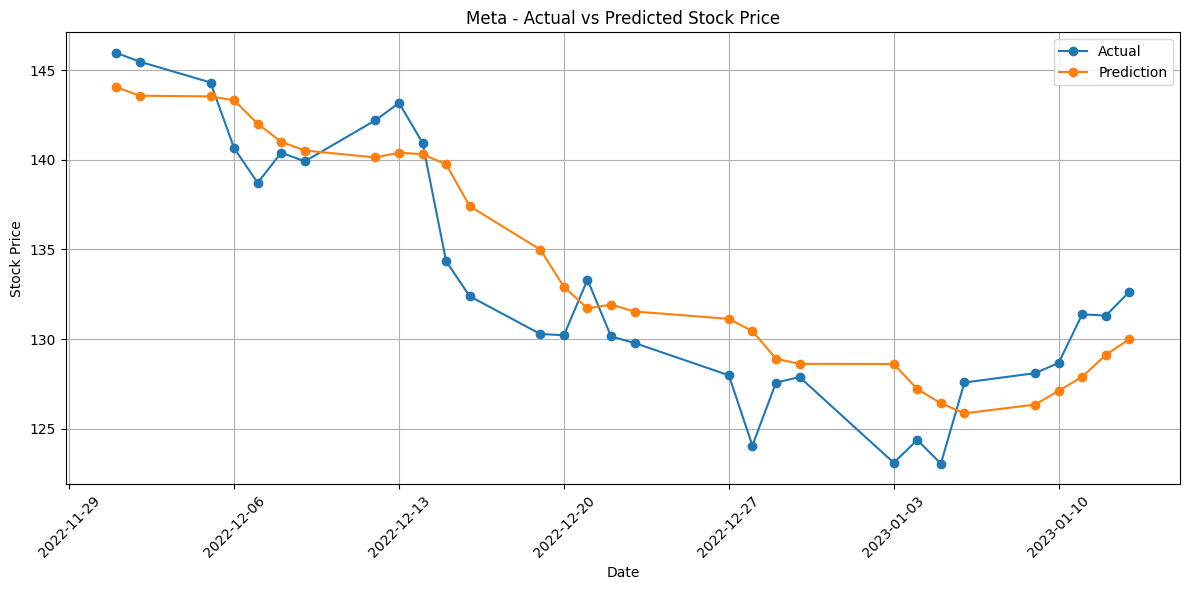

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#for company_name in ridge_plot_data:
dates, actual, predicted = plot_data["Apple"]

plt.figure(figsize=(12,6))

# Line chart with markers
plt.plot(dates, actual, label="Actual", marker='o')
plt.plot(dates, predicted, label="Prediction", marker='o')

plt.title(f"{company_name} - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Set x-axis to show ticks every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
bilstm_results = []
bilstm_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Google": df_google,
    "Meta": df_meta,
    "Nike": df_nike
}

for company_name, df in company_dfs.items():

    print(f"Processing (BiLSTM) {company_name}...")

    df = df.copy()
    df.set_index("Date", inplace=True)

    # Use stock + sentiment
    #df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment']]
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df[['Open', 'High', 'Low', 'Close', 'Volume','Oil', 'sentiment','Price_Movement']]
    df.dropna(inplace=True)

    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)

    seq_length = 30
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)
    split_index = split_index - seq_length

    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    test_dates = df.index[seq_length + split_index:]

    # BiLSTM Model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 6)

        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),

        Bidirectional(LSTM(32)),
        Dropout(0.3),

        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train WITHOUT EarlyStopping
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    predictions = model.predict(X_test, verbose=0)

    # Inverse transform
    last_sequences = X_test[:, -1, :]

    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()  # Close index

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # Actual values
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()

    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    bilstm_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    bilstm_plot_data[company_name] = (test_dates, y_test_actual, predictions_close)


Processing (BiLSTM) Amazon...
Processing (BiLSTM) Apple...
Processing (BiLSTM) Google...
Processing (BiLSTM) Meta...
Processing (BiLSTM) Nike...


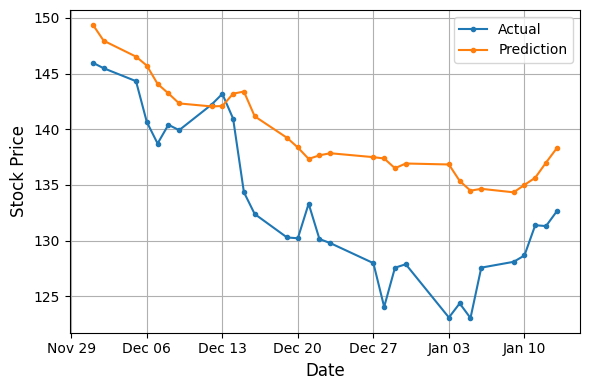

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = bilstm_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:

bilstm_results_df = pd.DataFrame(bilstm_results)
(bilstm_results_df)

,Company,RMSE,MAE
0,Amazon,8.25,7.74
1,Apple,7.35,6.47
2,Google,3.14,2.59
3,Meta,10.75,9.14
4,Nike,8.67,7.95


In [ ]:
#GLOBAL BILSTMMM:


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional

bilstm_results = []
bilstm_plot_data = {}

company_dfs = {
    "Amazon": df_amazon,
    "Apple": df_apple,
    "Nike": df_nike,
    "Google": df_google,
    "Meta": df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_train_data = []
processed_data = {}

seq_length = 30
split_date = "2022-12-01"

for company_name, df in company_dfs.items():

    print(f"Preparing {company_name}...")

    df = df.copy()
    df.set_index("Date", inplace=True)

    df['Price_Movement'] = df['Close'] - df['Open']

    df = df[['Open','High','Low','Close','Volume','sentiment','Oil','Price_Movement']]
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    X, y = create_sequences_multivariate(scaled_data, seq_length)

    split_index = df.index.get_loc(split_date)
    split_index = split_index - seq_length

    # Store TRAIN for global training
    all_train_data.append((X[:split_index], y[:split_index]))

    # Store TEST separately
    processed_data[company_name] = {
        "X_test": X[split_index:],
        "y_test": y[split_index:],
        "scaled_data": scaled_data,
        "scaler": scaler,
        "dates": df.index[seq_length + split_index:]
    }

# =========================
# STEP 2 — Combine training
# =========================

X_train_global = np.concatenate([x[0] for x in all_train_data], axis=0)
y_train_global = np.concatenate([x[1] for x in all_train_data], axis=0)

# =========================
# STEP 3 — Train ONE BiLSTM
# =========================

model = Sequential([
    Input(shape=(X_train_global.shape[1], X_train_global.shape[2])),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X_train_global,
    y_train_global,
    validation_split=0.1,
    epochs=40,
    batch_size=32,
    verbose=1
)

# =========================
# STEP 4 — Test per company
# =========================

for company_name, data in processed_data.items():

    print(f"Testing (Global BiLSTM) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    scaler = data["scaler"]
    scaled_data = data["scaled_data"]
    test_dates = data["dates"]

    predictions = model.predict(X_test, verbose=0)

    last_sequences = X_test[:, -1, :]

    # Inverse scaling
    predictions_full = np.zeros((len(predictions), scaled_data.shape[1]))
    predictions_full[:, :] = last_sequences
    predictions_full[:, 3] = predictions.flatten()

    predictions_actual = scaler.inverse_transform(predictions_full)
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # True values
    y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()

    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    bilstm_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    bilstm_plot_data[company_name] = (test_dates, y_test_actual, predictions_close)

# Final table
re=pd.DataFrame(bilstm_results)
re

Preparing Amazon...
Preparing Apple...
Preparing Nike...
Preparing Google...
Preparing Meta...
Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0612 - val_loss: 0.0060
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0149 - val_loss: 0.0015
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0122 - val_loss: 0.0013
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0098 - val_loss: 0.0024
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0094 - val_loss: 0.0012
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0089 - val_loss: 0.0011
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - val_loss: 0.0011
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0089 - val_loss: 0.0012
Epoch 9/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0076 - val_loss: 0.0011
Epoch 10/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0082 - val_loss: 0.0010
Epoch 11/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - 

,Company,RMSE,MAE
0,Amazon,3.48,3.01
1,Apple,3.12,2.50
2,Nike,5.69,4.72
3,Google,1.88,1.57
4,Meta,6.80,5.68


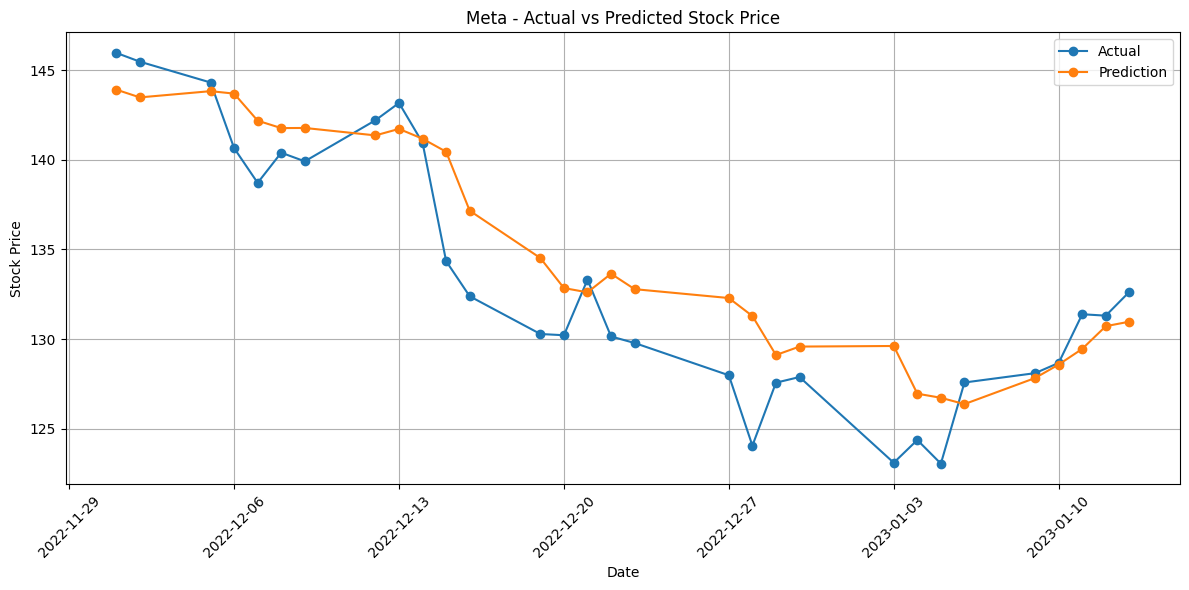

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#for company_name in ridge_plot_data:
dates, actual, predicted = bilstm_plot_data["Apple"]

plt.figure(figsize=(12,6))

# Line chart with markers
plt.plot(dates, actual, label="Actual", marker='o')
plt.plot(dates, predicted, label="Prediction", marker='o')

plt.title(f"{company_name} - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Set x-axis to show ticks every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell: Artificial Neural Network (ANN) for Stock Price Prediction
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ann_results = []
ann_plot_data = {}

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (ANN) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')

# 1. Create price movement feature FIRST on the main dataframe
    df['Price_Movement'] = df['Close'] - df['Open']

    # 2. Select ALL required columns (Make sure Close, SP500, and BTC are in here!)
    df_model = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment', 'Gold', 'Oil', 'Price_Movement']].copy()

    # 3. Drop NaNs
    df_model.dropna(inplace=True)

    # Create price movement feature

    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)


    # Features & target

    X = df_model[['Open', 'High', 'Low', 'Volume', 'sentiment','Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features and target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Build ANN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # EarlyStopping
    early_stop = EarlyStopping(
        monitor='loss',
        patience=10,
        verbose=0,
        restore_best_weights=True
    )

    # Train ANN
    model.fit(
        X_train_scaled, y_train_scaled,
        epochs=3000,
        batch_size=16,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predict
    pred_scaled = model.predict(X_test_scaled, verbose=0)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    ann_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    ann_plot_data[company_name] = (test_dates, y_test_actual, predictions)

# Convert to DataFrame
ann_results_df = pd.DataFrame(ann_results)
print("\n📊 ANN Results:")
ann_results_df

Processing (ANN) Apple...
Processing (ANN) Amazon...
Processing (ANN) Nike...
Processing (ANN) Google...
Processing (ANN) Meta...

📊 ANN Results:


,Company,RMSE,MAE
0,Apple,3.43,2.76
1,Amazon,5.48,4.68
2,Nike,4.79,4.30
3,Google,1.22,0.94
4,Meta,4.53,3.57


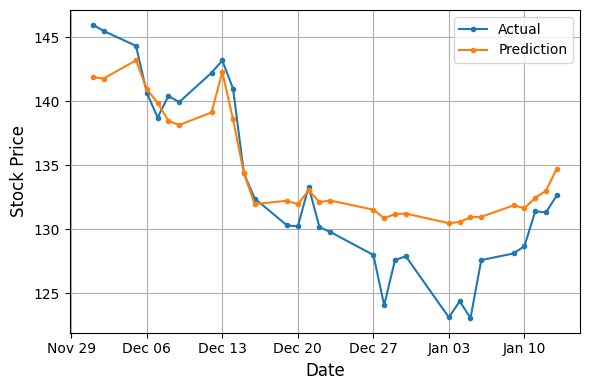

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = ann_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
#global annn


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

ann_results = []
ann_plot_data = {}

companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_X_train = []
all_y_train = []
processed_data = {}

split_date = "2022-12-01"

for company_name, df in companies_data.items():

    print(f"Preparing {company_name}...")

    df = df.copy()

    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Feature engineering
    df['Price_Movement'] = df['Close'] - df['Open']

    df_model = df[['Open','High','Low','Close','Volume','sentiment','Oil','Price_Movement']]
    df_model.dropna(inplace=True)

    split_index = df_model.index.get_loc(split_date)

    X = df_model[['Open','High','Low','Volume','sentiment','Oil','Price_Movement']]
    y = df_model['Close']

    # Split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Store for global training
    all_X_train.append(X_train)
    all_y_train.append(y_train)

    # Store test separately
    processed_data[company_name] = {
        "X_test": X_test,
        "y_test": y_test,
        "dates": df_model.index[split_index:]
    }

# =========================
# STEP 2 — Combine training
# =========================

X_train_global = pd.concat(all_X_train)
y_train_global = pd.concat(all_y_train)

# =========================
# STEP 3 — Scaling (GLOBAL)
# =========================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_global)
y_train_scaled = scaler_y.fit_transform(y_train_global.values.reshape(-1,1)).ravel()

# =========================
# STEP 4 — Train ONE ANN
# =========================

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=500,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# =========================
# STEP 5 — Test per company
# =========================

for company_name, data in processed_data.items():

    print(f"Testing (Global ANN) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    test_dates = data["dates"]

    # Use SAME scaler
    X_test_scaled = scaler_X.transform(X_test)

    pred_scaled = model.predict(X_test_scaled, verbose=0)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()

    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    ann_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    ann_plot_data[company_name] = (test_dates, y_test_actual, predictions)
# Final results
re=pd.DataFrame(ann_results)
re

Preparing Apple...
Preparing Amazon...
Preparing Nike...
Preparing Google...
Preparing Meta...
Epoch 1/500


/tmp/ipykernel_2629/1761785482.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/1761785482.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/1761785482.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/1761785482.py:46: SettingWithCopyWarning: 
A value is trying to be set on a c

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0330 - mae: 0.1324
Epoch 2/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0082 - mae: 0.0669
Epoch 3/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - mae: 0.0563
Epoch 4/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044 - mae: 0.0493
Epoch 5/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - mae: 0.0430
Epoch 6/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0429
Epoch 7/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0397
Epoch 8/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - mae: 0.0375
Epoch 9/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - mae: 0.0352
Epoch 10/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - mae: 0.0330
Epoch 11/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - mae: 0.0320
Epoch 12/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - mae: 0.0322
Epoch 13/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

,Company,RMSE,MAE
0,Apple,3.00,2.48
1,Amazon,6.64,6.14
2,Nike,2.10,1.85
3,Google,4.63,4.27
4,Meta,2.14,1.90


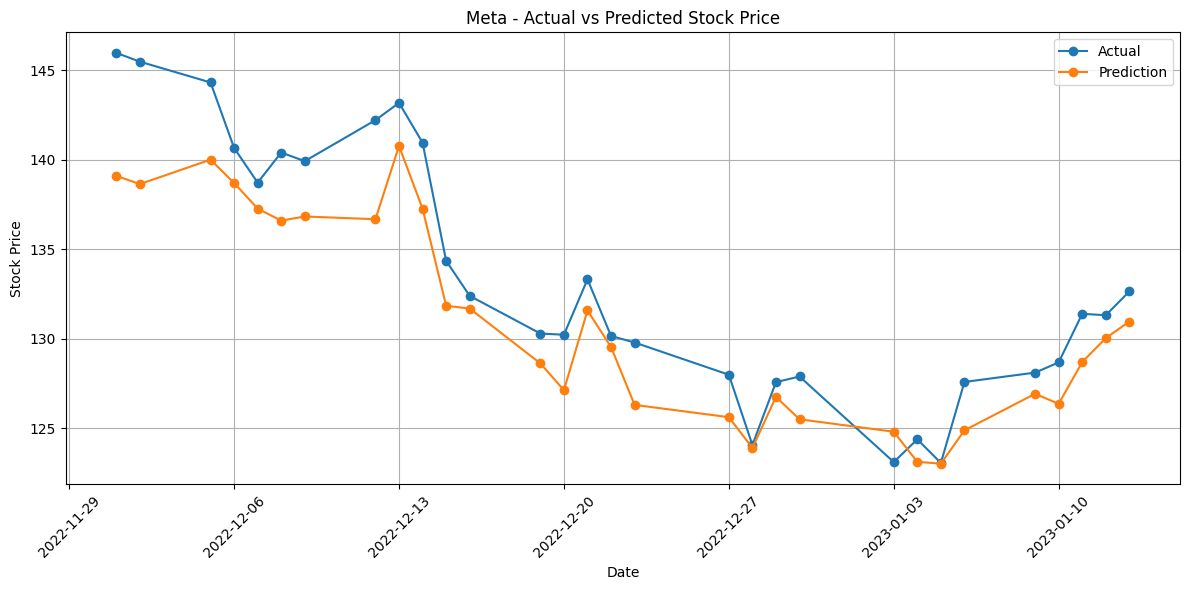

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#for company_name in ridge_plot_data:
dates, actual, predicted = ann_plot_data["Apple"]

plt.figure(figsize=(12,6))

# Line chart with markers
plt.plot(dates, actual, label="Actual", marker='o')
plt.plot(dates, predicted, label="Prediction", marker='o')

plt.title(f"{company_name} - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Set x-axis to show ticks every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell: Random Forest (RF) for Stock Price Prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

rf_results = []
rf_plot_data = {}

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (RF) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')
    df['Price_Movement'] = df['Close'] - df['Open']
    # Select required columns (including sentiment)
    df_model = df[['Open', 'High', 'Low', 'Close', 'Volume', 'sentiment', 'Gold','Oil_Return', 'Oil', 'Price_Movement']].copy()
    df_model.dropna(inplace=True)


    # Create price movement feature
    df_model['Price_Movement'] = df_model['Close'] - df_model['Open']

    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)

    # Features & Target (NOW INCLUDING SENTIMENT!)
    X = df_model[['Open', 'High', 'Low', 'Volume' ,'sentiment', 'Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features & target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = rf.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    rf_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    rf_plot_data[company_name] = (test_dates, y_test_actual, predictions)

    # Optional: Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\n{company_name} - Top features:")
    print(feature_importance.head(3))

# Convert results to DataFrame
rf_results_df = pd.DataFrame(rf_results)
print("\n📊 Random Forest Results:")
rf_results_df

Processing (RF) Apple...

Apple - Top features:
          feature  importance
1            High    0.677797
2             Low    0.312489
5  Price_Movement    0.006521
Processing (RF) Amazon...

Amazon - Top features:
  feature  importance
2     Low    0.707835
1    High    0.216825
0    Open    0.072624
Processing (RF) Nike...

Nike - Top features:
  feature  importance
2     Low    0.657794
1    High    0.298587
0    Open    0.041721
Processing (RF) Google...

Google - Top features:
  feature  importance
1    High    0.536984
2     Low    0.394934
0    Open    0.065105
Processing (RF) Meta...

Meta - Top features:
  feature  importance
2     Low    0.481581
1    High    0.314232
0    Open    0.203025

📊 Random Forest Results:


,Company,RMSE,MAE
0,Apple,2.53,1.70
1,Amazon,3.85,3.04
2,Nike,0.80,0.61
3,Google,1.08,0.87
4,Meta,2.76,2.23


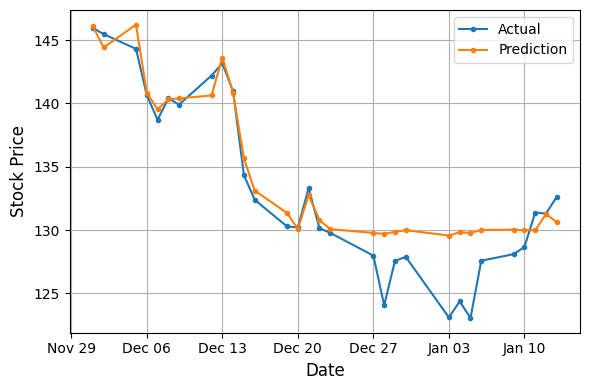

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = rf_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
#GLOBALL RANDOMFORESTT

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

rf_results = []
rf_plot_data = {}

companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_X_train = []
all_y_train = []
processed_data = {}

split_date = "2022-12-01"

for company_name, df in companies_data.items():

    print(f"Preparing {company_name}...")

    df = df.copy()

    if 'Date' in df.columns:
        df = df.set_index('Date')

    df['Price_Movement'] = df['Close'] - df['Open']

    df_model = df[['Open','High','Low','Close','Volume','sentiment','Oil_Return','Oil','Price_Movement']]
    df_model.dropna(inplace=True)

    split_index = df_model.index.get_loc(split_date)

    X = df_model[['Open','High','Low','Volume','sentiment','Oil','Price_Movement']]
    y = df_model['Close']

    # Split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Store global training data
    all_X_train.append(X_train)
    all_y_train.append(y_train)

    # Store test separately
    processed_data[company_name] = {
        "X_test": X_test,
        "y_test": y_test,
        "dates": df_model.index[split_index:]
    }

# =========================
# STEP 2 — Combine training
# =========================

X_train_global = pd.concat(all_X_train)
y_train_global = pd.concat(all_y_train)

# =========================
# STEP 3 — Scaling (GLOBAL)
# =========================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_global)
y_train_scaled = scaler_y.fit_transform(y_train_global.values.reshape(-1,1)).ravel()

# =========================
# STEP 4 — Train ONE RF
# =========================

rf = RandomForestRegressor(
    n_estimators=200,          # 🔥 stronger than before
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train_scaled)

# =========================
# STEP 5 — Test per company
# =========================

for company_name, data in processed_data.items():

    print(f"Testing (Global RF) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    test_dates = data["dates"]

    X_test_scaled = scaler_X.transform(X_test)

    pred_scaled = rf.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()

    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    rf_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    rf_plot_data[company_name] = (test_dates, y_test_actual, predictions)

# =========================
# STEP 6 — Feature Importance (GLOBAL)
# =========================

feature_importance = pd.DataFrame({
    'feature': X_train_global.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔥 GLOBAL Feature Importance:")
print(feature_importance)

# Final results
print(pd.DataFrame(rf_results))

Preparing Apple...
Preparing Amazon...
Preparing Nike...
Preparing Google...
Preparing Meta...


/tmp/ipykernel_2629/3113103115.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3113103115.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3113103115.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3113103115.py:42: SettingWithCopyWarning: 
A value is trying to be set on a c

Testing (Global RF) Apple...
Testing (Global RF) Amazon...
Testing (Global RF) Nike...
Testing (Global RF) Google...
Testing (Global RF) Meta...

🔥 GLOBAL Feature Importance:
          feature  importance
2             Low    0.510019
1            High    0.409861
0            Open    0.070974
5             Oil    0.008085
6  Price_Movement    0.000868
3          Volume    0.000130
4       sentiment    0.000063
  Company  RMSE   MAE
0   Apple  0.77  0.60
1  Amazon  0.93  0.74
2    Nike  0.52  0.42
3  Google  0.76  0.62
4    Meta  0.71  0.58


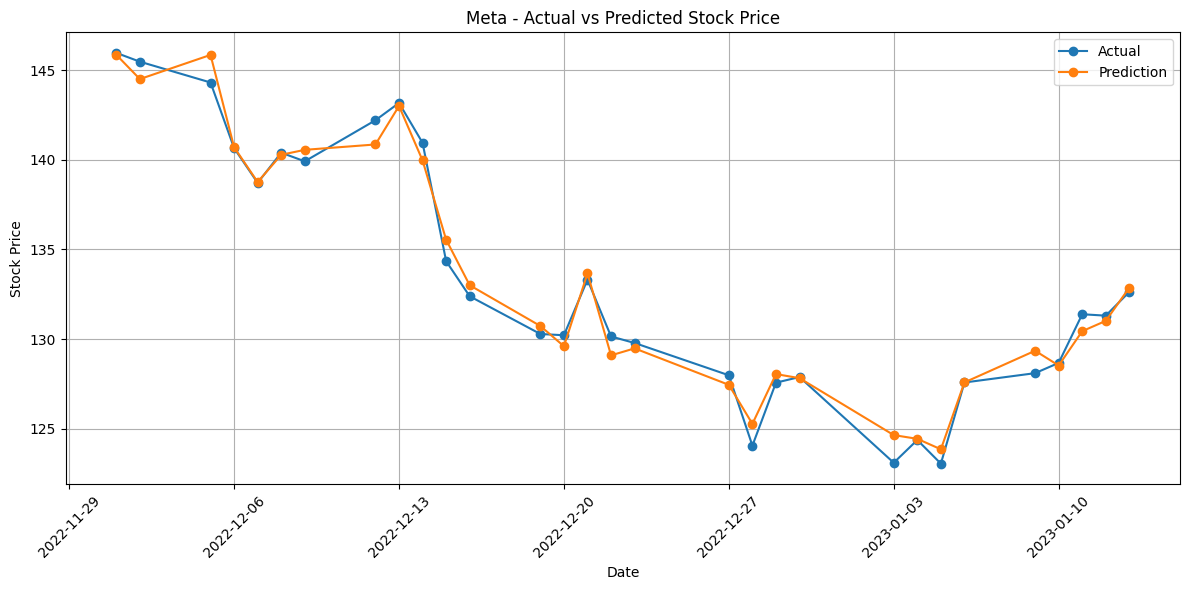

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#for company_name in ridge_plot_data:
dates, actual, predicted = rf_plot_data["Apple"]

plt.figure(figsize=(12,6))

# Line chart with markers
plt.plot(dates, actual, label="Actual", marker='o')
plt.plot(dates, predicted, label="Prediction", marker='o')

plt.title(f"{company_name} - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Set x-axis to show ticks every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

xgb_results = []
xgb_plot_data = {}

# Dictionary of your existing dataframes
companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

for company_name, df in companies_data.items():

    print(f"Processing (XGBoost) {company_name}...")

    # Make sure Date is index
    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Select required columns (with sentiment)
    df['Price_Movement'] = df['Close'] - df['Open']
    df_model = df[['Open','Close', 'High', 'Low', 'Volume', 'sentiment', 'Oil_Return', 'Gold', 'Oil',  'Price_Movement']].copy()
    df_model.dropna(inplace=True)

    # Create price movement feature


    # Define split date
    split_date = "2022-12-01"
    split_index = df_model.index.get_loc(split_date)

    # Features & Target (INCLUDING SENTIMENT!)
    X = df_model[['Open', 'High', 'Low', 'Volume', 'sentiment', 'Price_Movement']]
    y = df_model['Close']

    # Time-series split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    test_dates = df_model.index[split_index:]

    # Scale features & target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Train XGBoost model
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = xgb.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    xgb_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    xgb_plot_data[company_name] = (test_dates, y_test_actual, predictions)

    # Optional: Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\n{company_name} - Top features:")
    print(feature_importance.head(3))

# Convert results to DataFrame
xgb_results_df = pd.DataFrame(xgb_results)
print("\n📊 XGBoost Results:")
xgb_results_df

Processing (XGBoost) Apple...

Apple - Top features:
  feature  importance
2     Low    0.616243
1    High    0.363854
0    Open    0.011992
Processing (XGBoost) Amazon...

Amazon - Top features:
  feature  importance
2     Low    0.791994
1    High    0.198498
0    Open    0.007146
Processing (XGBoost) Nike...

Nike - Top features:
  feature  importance
2     Low    0.749349
1    High    0.236831
0    Open    0.012102
Processing (XGBoost) Google...

Google - Top features:
  feature  importance
1    High    0.505836
2     Low    0.441956
0    Open    0.049087
Processing (XGBoost) Meta...

Meta - Top features:
  feature  importance
1    High    0.407157
0    Open    0.303518
2     Low    0.287965

📊 XGBoost Results:


,Company,RMSE,MAE
0,Apple,2.00,1.50
1,Amazon,2.53,2.01
2,Nike,0.65,0.48
3,Google,1.01,0.77
4,Meta,2.60,2.12


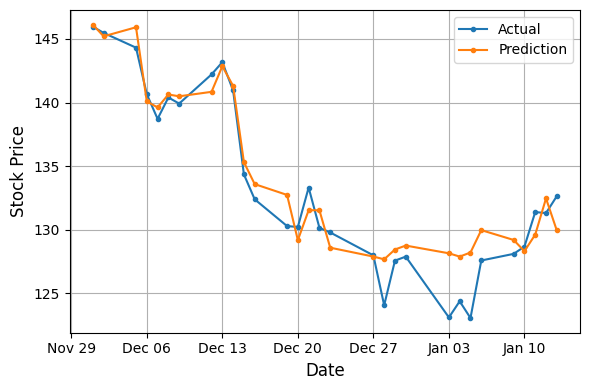

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = xgb_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
#GLOBAL XGB

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

xgb_results = []
xgb_plot_data = {}

companies_data = {
    'Apple': df_apple,
    'Amazon': df_amazon,
    'Nike': df_nike,
    'Google': df_google,
    'Meta': df_meta
}

# =========================
# STEP 1 — Prepare ALL data
# =========================

all_X_train = []
all_y_train = []
processed_data = {}

split_date = "2022-12-01"

for company_name, df in companies_data.items():

    print(f"Preparing {company_name}...")

    df = df.copy()

    if 'Date' in df.columns:
        df = df.set_index('Date')

    df['Price_Movement'] = df['Close'] - df['Open']

    df_model = df[['Open','High','Low','Close','Volume','sentiment','Oil_Return','Gold','Oil','Price_Movement']]
    df_model.dropna(inplace=True)

    split_index = df_model.index.get_loc(split_date)

    X = df_model[['Open','High','Low','Volume','sentiment','Price_Movement']]
    y = df_model['Close']

    # Split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Store for GLOBAL training
    all_X_train.append(X_train)
    all_y_train.append(y_train)

    # Store test separately
    processed_data[company_name] = {
        "X_test": X_test,
        "y_test": y_test,
        "dates": df_model.index[split_index:]
    }

# =========================
# STEP 2 — Combine training
# =========================

X_train_global = pd.concat(all_X_train)
y_train_global = pd.concat(all_y_train)

# =========================
# STEP 3 — GLOBAL Scaling
# =========================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_global)
y_train_scaled = scaler_y.fit_transform(y_train_global.values.reshape(-1,1)).ravel()

# =========================
# STEP 4 — Train ONE XGBoost
# =========================

xgb = XGBRegressor(
    n_estimators=300,          # 🔥 stronger
    max_depth=6,
    learning_rate=0.05,        # 🔥 smoother learning
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train_scaled)

# =========================
# STEP 5 — Test per company
# =========================

for company_name, data in processed_data.items():

    print(f"Testing (Global XGB) {company_name}...")

    X_test = data["X_test"]
    y_test = data["y_test"]
    test_dates = data["dates"]

    X_test_scaled = scaler_X.transform(X_test)

    pred_scaled = xgb.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()

    y_test_actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    xgb_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    xgb_plot_data[company_name] = (test_dates, y_test_actual, predictions)

# =========================
# STEP 6 — GLOBAL Feature Importance
# =========================

feature_importance = pd.DataFrame({
    'feature': X_train_global.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔥 GLOBAL XGBoost Feature Importance:")
print(feature_importance)

# Final results
print(pd.DataFrame(xgb_results))

Preparing Apple...
Preparing Amazon...
Preparing Nike...
Preparing Google...
Preparing Meta...


/tmp/ipykernel_2629/3669483050.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3669483050.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3669483050.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.dropna(inplace=True)
/tmp/ipykernel_2629/3669483050.py:42: SettingWithCopyWarning: 
A value is trying to be set on a c

Testing (Global XGB) Apple...
Testing (Global XGB) Amazon...
Testing (Global XGB) Nike...
Testing (Global XGB) Google...
Testing (Global XGB) Meta...

🔥 GLOBAL XGBoost Feature Importance:
          feature  importance
2             Low    0.668434
1            High    0.278212
0            Open    0.051186
3          Volume    0.000956
5  Price_Movement    0.000922
4       sentiment    0.000290
  Company  RMSE   MAE
0   Apple  0.65  0.58
1  Amazon  0.66  0.55
2    Nike  0.52  0.40
3  Google  0.57  0.47
4    Meta  0.69  0.54


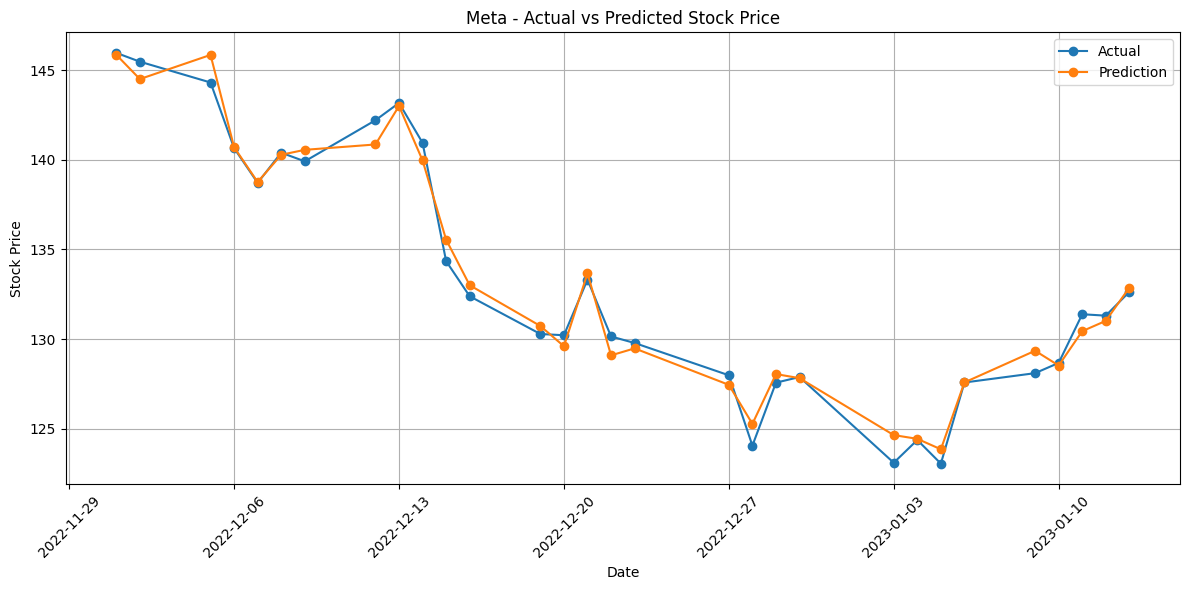

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#for company_name in ridge_plot_data:
dates, actual, predicted = rf_plot_data["Apple"]

plt.figure(figsize=(12,6))

# Line chart with markers
plt.plot(dates, actual, label="Actual", marker='o')
plt.plot(dates, predicted, label="Prediction", marker='o')

plt.title(f"{company_name} - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")

# Set x-axis to show ticks every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()